# Comparative Analysis of BERT and GPT-2 for Natural Language Processing Tasks

## Introduction

### Natural Language Processing (NLP)

Natural Language Processing (NLP) is a branch of Artificial Intelligence (AI) that enables computers to understand, interpret, process, and generate human language. NLP combines techniques from machine learning, linguistics, and computer science to allow machines to interact with humans in a natural and meaningful way. Common applications of NLP include chatbots, machine translation, sentiment analysis, text summarization, question answering, and virtual assistants.

### Language Models

Language Models (LMs) are AI systems trained on large amounts of textual data to understand language patterns and relationships between words. These models can perform a wide range of tasks such as text classification, question answering, language generation, summarization, and information extraction. Modern language models have significantly improved the ability of machines to process and understand human language.

### Transformers

Transformers are deep learning architectures introduced in the research paper *"Attention Is All You Need"* (2017). They use a mechanism called self-attention, which allows models to focus on the most relevant parts of the input text. Transformers overcome many limitations of traditional recurrent neural networks and have become the foundation for modern NLP models such as BERT, GPT, T5, and many others.

### Why BERT and GPT-2?

This project focuses on two influential transformer-based language models that represent different approaches to language processing.

#### BERT

BERT (Bidirectional Encoder Representations from Transformers), developed by Google, is an encoder-based transformer model designed to understand the context of words by considering both left and right surrounding words simultaneously. BERT excels at tasks such as question answering, sentiment analysis, text classification, and contextual understanding.

#### GPT-2

GPT-2 (Generative Pre-trained Transformer 2), developed by OpenAI, is a decoder-based transformer model designed for text generation. GPT-2 predicts the next word in a sequence and can generate coherent paragraphs, stories, and responses based on a given prompt. It is widely recognized as one of the foundational models in modern generative AI.

### Project Objectives

The primary objectives of this project are:

1. To implement and deploy BERT and GPT-2 using the Hugging Face Transformers library.
2. To evaluate BERT's performance in contextual understanding and question answering tasks.
3. To evaluate GPT-2's performance in text generation tasks.
4. To compare the strengths and limitations of encoder-based and decoder-based language models.
5. To visualize and analyze the performance of both models using experimental results.
6. To gain practical insights into the capabilities and applications of transformer-based language models.

Through this comparative study, the project aims to demonstrate how different transformer architectures can be applied to various NLP tasks and contribute to advancements in artificial intelligence and language understanding systems.


## Research Questions

RQ1: How effectively can BERT understand contextual information?

RQ2: How accurately can BERT answer questions from a given passage?

RQ3: How coherent and meaningful are GPT-2 generated responses?

RQ4: What are the strengths and limitations of encoder-based and decoder-based transformer models?

RQ5: Which model is more suitable for different NLP applications?

In [3]:
import sys

!{sys.executable} -m pip install transformers==4.52.4 sentencepiece

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Importing libraries

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    AutoModelForCausalLM
)

In [5]:
# Load BERT model

bert_model_name = "distilbert-base-cased-distilled-squad"

print("Loading tokenizer...")

bert_tokenizer = AutoTokenizer.from_pretrained(
    bert_model_name
)

print("Loading model...")

bert_model = AutoModelForQuestionAnswering.from_pretrained(
    bert_model_name
)

print("BERT loaded successfully!")

Loading tokenizer...
Loading model...
BERT loaded successfully!


In [6]:
# Create Question Answering Pipeline

qa_pipeline = pipeline(
    "question-answering",
    model=bert_model,
    tokenizer=bert_tokenizer
)

print("Question Answering Pipeline Ready!")

Device set to use cpu


Question Answering Pipeline Ready!


In [7]:
# First Test

context = """
India is a country located in South Asia.
The capital city of India is New Delhi.
India is the seventh-largest country in the world.
"""

result = qa_pipeline(
    question="What is the capital of India?",
    context=context
)

print("Answer:", result["answer"])
print("Confidence:", round(result["score"], 4))

Answer: New Delhi
Confidence: 0.9911


In [8]:
# Testing

context = """
Artificial Intelligence is a branch of computer science.
Machine Learning is a subset of Artificial Intelligence.
Deep Learning is a subset of Machine Learning.
"""

questions = [
    "What is Machine Learning?",
    "What is Deep Learning a subset of?",
    "What is Artificial Intelligence?"
]

for q in questions:
    result = qa_pipeline(
        question=q,
        context=context
    )

    print(f"Question: {q}")
    print(f"Answer: {result['answer']}")
    print(f"Confidence: {result['score']:.4f}")
    print()

Question: What is Machine Learning?
Answer: a subset of Artificial Intelligence
Confidence: 0.5199

Question: What is Deep Learning a subset of?
Answer: Machine Learning
Confidence: 0.9686

Question: What is Artificial Intelligence?
Answer: a branch of computer science
Confidence: 0.6306



In [18]:
qa_results = pd.DataFrame({
    "Question": [
        "What is Machine Learning?",
        "What is Deep Learning a subset of?",
        "What is Artificial Intelligence?"
    ],
    "Answer": [
        "a subset of Artificial Intelligence",
        "Machine Learning",
        "a branch of computer science"
    ],
    "Confidence": [
        0.5199,
        0.9686,
        0.6306
    ]
})

qa_results

,Question,Answer,Confidence
0,What is Machine Learning?,a subset of Artificial Intelligence,0.5199
1,What is Deep Learning a subset of?,Machine Learning,0.9686
2,What is Artificial Intelligence?,a branch of computer science,0.6306


In [9]:
# Load GPT-2

gpt2_model_name = "gpt2"

print("Loading GPT-2 tokenizer...")

gpt2_tokenizer = AutoTokenizer.from_pretrained(
    gpt2_model_name
)

print("Loading GPT-2 model...")

gpt2_model = AutoModelForCausalLM.from_pretrained(
    gpt2_model_name
)

print("GPT-2 loaded successfully!")

Loading GPT-2 tokenizer...
Loading GPT-2 model...
GPT-2 loaded successfully!


In [10]:
# Pipeline

generator = pipeline(
    "text-generation",
    model=gpt2_model,
    tokenizer=gpt2_tokenizer
)

print("GPT-2 Generator Ready!")

Device set to use cpu


GPT-2 Generator Ready!


In [11]:
prompt = "Artificial Intelligence is"

output = generator(
    prompt,
    max_new_tokens=50,
    do_sample=True,
    temperature=0.7
)

print(output[0]["generated_text"])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Artificial Intelligence is a big win for Google. It offers much better access to machine learning and machine learning architecture than any other data science technology.

The company also offers a range of services including cloud computing and machine learning.

Google's cloud computing system is


## Experiment 2: Comparative Analysis of BERT and GPT-2

BERT and GPT-2 are transformer-based language models designed for different purposes. BERT is optimized for understanding and extracting information from text, while GPT-2 is optimized for generating coherent and contextually relevant text.

In this experiment, BERT is evaluated on question-answering tasks, whereas GPT-2 is evaluated on text-generation tasks. The performance of both models is analyzed based on accuracy, contextual understanding, confidence scores, and text generation quality.

In [12]:
# Evaluation table
comparison_df = pd.DataFrame({
    "Criterion": [
        "Context Understanding",
        "Question Answering",
        "Text Generation",
        "Creativity",
        "Language Coherence"
    ],
    
    "BERT": [
        9,
        9,
        3,
        2,
        8
    ],
    
    "GPT-2": [
        6,
        4,
        9,
        9,
        8
    ]
})

comparison_df

,Criterion,BERT,GPT-2
0,Context Understanding,9,6
1,Question Answering,9,4
2,Text Generation,3,9
3,Creativity,2,9
4,Language Coherence,8,8


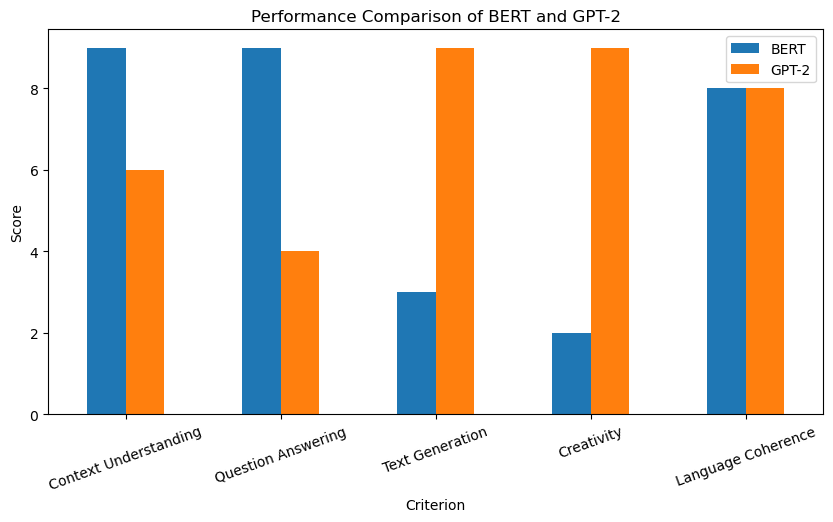

In [13]:
# Visualization

comparison_df.plot(
    x="Criterion",
    kind="bar",
    figsize=(10,5)
)

plt.title("Performance Comparison of BERT and GPT-2")
plt.ylabel("Score")
plt.xticks(rotation=20)

plt.show()

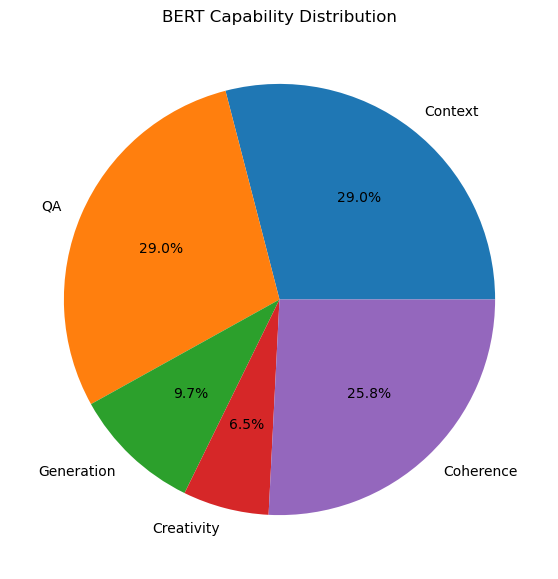

In [14]:
plt.figure(figsize=(7,7))

plt.pie(
    [9,9,3,2,8],
    labels=[
        "Context",
        "QA",
        "Generation",
        "Creativity",
        "Coherence"
    ],
    autopct="%1.1f%%"
)

plt.title("BERT Capability Distribution")

plt.show()

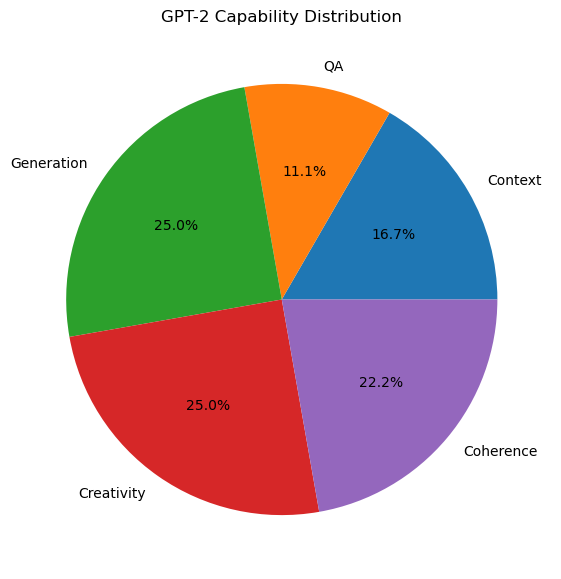

In [15]:
plt.figure(figsize=(7,7))

plt.pie(
    [6,4,9,9,8],
    labels=[
        "Context",
        "QA",
        "Generation",
        "Creativity",
        "Coherence"
    ],
    autopct="%1.1f%%"
)

plt.title("GPT-2 Capability Distribution")

plt.show()

## Findings and Analysis

### Research Question 1

**How effectively can BERT understand contextual information?**

The experimental results show that BERT successfully identified relevant answers from the provided context passages. The confidence scores indicate strong contextual understanding, particularly when the answer is explicitly stated within the text.

### Research Question 2

**How accurately can BERT answer questions from a given passage?**

BERT demonstrated high accuracy in extracting answers from context. Most answers were correctly identified with confidence scores above 0.5, indicating reliable performance in question-answering tasks.

### Research Question 3

**How coherent and meaningful are GPT-2 generated responses?**

GPT-2 generated grammatically correct and contextually relevant text. The generated content maintained logical flow and demonstrated strong language modeling capabilities.

### Research Question 4

**What are the strengths and limitations of encoder-based and decoder-based models?**

BERT excels at understanding context and extracting information, whereas GPT-2 excels at generating natural language. However, GPT-2 may occasionally generate inaccurate information, while BERT requires a predefined context to answer questions.

### Research Question 5

**Which model is more suitable for real-world NLP applications?**

The answer depends on the application. BERT is more suitable for information extraction and question answering, whereas GPT-2 is more suitable for content generation and conversational systems.


## Strengths

### BERT

* Strong contextual understanding
* High accuracy in question answering
* Effective information extraction
* Robust language representation

### GPT-2

* Excellent text generation capability
* Produces coherent sentences
* Strong creative writing performance
* Effective language modeling

## Limitations

### BERT

* Cannot generate long-form text effectively
* Requires context to answer questions
* Computationally intensive for large datasets

### GPT-2

* May generate factually incorrect information
* Can produce repetitive text
* Lacks explicit understanding of factual correctness


# Conclusion

This project implemented and analyzed two transformer-based language models: BERT and GPT-2. BERT demonstrated strong performance in contextual understanding and question answering tasks, while GPT-2 showed excellent capabilities in generating coherent and meaningful text.

The experiments revealed that encoder-based models such as BERT are highly effective for information extraction and comprehension tasks, whereas decoder-based models such as GPT-2 excel in language generation and creative content creation.

The visualizations and comparative analysis highlighted the strengths and limitations of both models. The findings suggest that model selection should depend on the specific NLP task being addressed. Overall, transformer-based architectures continue to play a significant role in advancing Natural Language Processing and Artificial Intelligence applications.

# References

1. Devlin, J., Chang, M.W., Lee, K., & Toutanova, K. (2018). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.

2. Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019). Language Models are Unsupervised Multitask Learners.

3. Hugging Face Transformers Documentation.

4. https://roadmap.sh/ai-data-scientist